In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('train.csv')

In [4]:
df["comment"]

0                        ทำไมปล่อยให้จุดพลุกันสนั่นหวั่นไหว
1         แจ้งว่าการจุดพลุต้องขออนุญาต ทำไมจุดกันมากมายข...
2         คาดว่ามีการจุดพลุไม่ขอทางกรุงเทพให้ถูกต้อง ส่ง...
3         ไม่แน่ใจ กทม อนุญาตให้ร้านชอคโกแลตวิลจุพลุถึงก...
4         ไม่ทราบใครจัดงานปีใหม่ละแวกนี้ เปิดเสียงเพลงดั...
                                ...                        
306414                                       ขับรถบนทางเท้า
306415    ฝาท่อน้ำเหล็ก ข้างร้านเดอะโลคอล ซ.สุชุมวิท 23 ...
306416    กรุณาตรวจสอบการดำเนินการก่อสร้างฟุตบาทถนนพุทธบ...
306417    ถนนศรีอยุธยาชำรุด บริเวณหน้าทางเข้าตึกวรรณสรณ์...
306418    งานก่อปรับปรุงก่อสร้างซอยพระรามที่2\nซอย62 ในซ...
Name: comment, Length: 306419, dtype: object

In [5]:
import re
from collections import Counter
import pandas as pd

# Function to extract HTML tags
def find_html_tags(text):
    if not isinstance(text, str):
        return []
    return re.findall(r'<[^>]+>', text)

# Apply to find tags
df['html_tags'] = df['comment'].apply(find_html_tags)
all_tags = [tag for tags in df['html_tags'] for tag in tags]

# Count and display most common tags
tag_counts = Counter(all_tags)
print("Top 20 detected HTML tags:")
for tag, count in tag_counts.most_common(20):
    print(f"{tag}: {count}")

# Show examples of comments with tags
print("\nExamples of comments with HTML tags:")
print(df[df['html_tags'].map(len) > 0]['comment'].head().values)

Top 20 detected HTML tags:
<footpath>: 1
<กัดกัน>: 1
<แจ้งครั้งที่3>: 1
<เดิมถังขยะอยู่ฝั่งหลังกระทรวงมหาดไทย>: 1

Examples of comments with HTML tags:
['ถนนระนอง1 ทางเท้า<footpath> ใช้เดินไม่ได้ มีสิ่งกีดขวาง บางช่วงมีถนนชำรุด'
 'เลี้ยงสัตว์นอกบ้าน ขับถ่ายเต็มซอย ส่งเสียงดัง<กัดกัน> ตอนกลางคืน รบกวนผู้อื่น'
 'คนเร่ร่อน นอนบนสะพานวิทยุ <แจ้งครั้งที่3>'
 'ถนนเฟื่องนคร ตรงหลังกระทรวงมหาดไทย โดนเก็บถังขยะส่วนกลางไปหมด<เดิมถังขยะอยู่ฝั่งหลังกระทรวงมหาดไทย>,, จะให้ไปทิ้งขยะตรงไหนคะ หรือจะเอาถังขยะมาตั้งให้เหมือนเดิม ไม่มีที่ทิ้งขยะค่ะ']


In [9]:
# Function to find emojis (simplified regex for common emoji ranges)
def find_emojis(text):
    if not isinstance(text, str):
        return []
    # Unicode ranges for many emojis
    emoji_pattern = re.compile(r'[\u263a-\U0001f645]')
    return emoji_pattern.findall(text)

df['emojis'] = df['comment'].apply(find_emojis)
all_emojis = [e for emojis in df['emojis'] for e in emojis]

# Count and display most common emojis
emoji_counts = Counter(all_emojis)
print("Top 20 detected emojis:")
for emo, count in emoji_counts.most_common(20):
    print(f"{emo}: {count}")

# Show examples of comments with emojis
print("\nExamples of comments with emojis:")
print(df[df['emojis'].map(len) > 0]['comment'].head().values[0])

Top 20 detected emojis:
️: 16572
👏: 9625
👩: 7908
✌: 6416
📸: 3711
📌: 3624
🔊: 3276
👷: 3219
😱: 2905
🔧: 2865
💪: 2861
📢: 2854
♀: 1792
💥: 1604
🎤: 1364
🏃: 1263
♂: 1215
🕳: 1188
🙅: 960
👉: 906

Examples of comments with emojis:
📢🔊 แจ้งป้ายเถื่อน ป้ายกองโจร 😱 ติดป้าย ผิด พรบ.ความสะอาด และความเป็นระเบียบเรียบร้อยของบ้านเมือง❌😤😠🙅‍♀️🙅‍♂️
🎤โฆษณาด้วยการปิด ทิ้ง หรือ โปรยแผ่นประกาศหรือใบปลิว ในที่สาธารณะ โดยไม่ได้รับอนุญาตมาตรา 10 แห่ง พ.ร.บ.รักษาความสะอาด พ.ศ. ๒๕๓๕
📸
📌ตรงตั้งแต่อู่ประสพโชค
🛣️ถนน ในซอยรามอินทรา 58
🙏👷👩‍🔧ขอขอบคุณ เจ้าหน้าที่ทุกท่าน ในการจัดการปัญหานี้✌️✌️💪👏👏👏


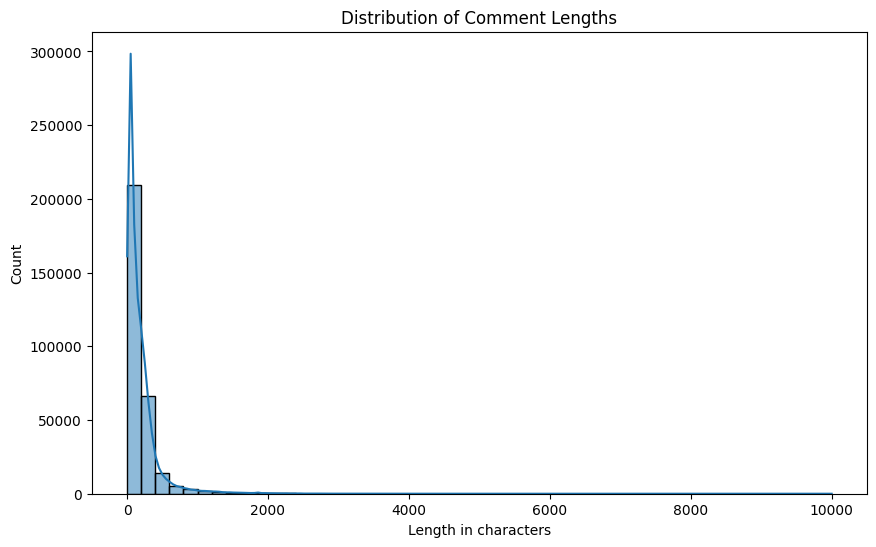

Comment Length Statistics:
count    304284.000000
mean        189.298507
std         274.921040
min           1.000000
25%          45.000000
50%         112.000000
75%         235.000000
max        9999.000000
Name: comment_length, dtype: float64

Top 5 Longest Comments:
Length: 9999.0
Comment: เรียนท่านผู้ว่าราชการกรุงเทพมหานคร อธิบดีกรมเจ้าท่า และผู้อำนวยการเขตสัมพันธวงศ์
เลขรับแจ้ง 2024-H33YVA เมื่อวันที่ 30 สิงหาคม 2567 เนื่องด้วยเหตุการณ์ส่วนต่อขยายร้านอาหารถล่ม ทรุดตัวของร้านอาหารเมื่อ...
--------------------------------------------------
Length: 9778.0
Comment: ไม่ใช่เจ้ของพื้นที่น่ะเข้าใจ ไม่ใช่หน่วยงานผู้บังคับบัญชาของการรถไฟแห่งประเทศไทยก็ทราบ แต่ส่งมาให้ดูหลายทีแล้วว่า กรุงเทพมหานคร ไปทำถนน ทำทางเท้า ทำฝาท่อระบายน้ำ ทำสิ่งก่อสร้าง จากงบที่ได้มาจากรัฐบาล ...
--------------------------------------------------
Length: 9776.0
Comment: ไม่ใช่เจ้าของพื้นที่น่ะเข้าใจ ไม่ใช่หน่วยงานผู้บังคับบัญชาของการรถไฟแห่งประเทศไทยก็ทราบ แต่ส่งมาให้ดูหลายทีแล้วว่า กรุงเทพมหานคร ไปทำถนน ทำทางเท้

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate lengths
df['comment_length'] = df['comment'].str.len()

# Plot distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['comment_length'], bins=50, kde=True)
plt.title('Distribution of Comment Lengths')
plt.xlabel('Length in characters')
plt.ylabel('Count')
plt.show()

# Show statistics
print("Comment Length Statistics:")
print(df['comment_length'].describe())

# Show top 5 longest comments
print("\nTop 5 Longest Comments:")
longest_comments = df.nlargest(5, 'comment_length')
for idx, row in longest_comments.iterrows():
    print(f"Length: {row['comment_length']}")
    print(f"Comment: {row['comment'][:200]}...") # truncate for display
    print("-" * 50)